In [1]:
import torch
import pandas as pd
from torch_geometric.data import Data
from pathlib import Path
import os
os.chdir(Path().cwd().parent)
from modelling import get_dataframes
from modelling.metrics.metricstracker import MetricsTracker
import datetime
from graph_modelling.utils.load_data import load_train_val_data, load_test_data


Running __init__.py for data pipeline...
Modelling package initialized

/opt/rocm/lib/libamd_smi.so: cannot open shared object file: No such file or directory
Unable to find amdsmi library try installing amd-smi-lib from your package manager


2025-03-20 16:26:14.108071: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-20 16:26:14.108197: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-20 16:26:14.108448: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-20 16:26:14.204841: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-20 16:26:15.863900: W tensorflow/compiler/

In [2]:
HABROK = bool(0)                  # set to True if using HABROK; it will print
                                  # all stdout to a .txt file to log progress
BASE_DIR = Path.cwd()
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_combined"
ALL_DIR = DATA_DIR / "all"

print("BASE_DIR: ", BASE_DIR)
print("MODEL_PATH: ", MODEL_PATH)

torch.manual_seed(34)             # set seed for reproducibility

N_HOURS_U = 72                    # number of hours to use for input
N_HOURS_Y = 24                    # number of hours to predict
N_HOURS_STEP = 24                 # "sampling rate" in hours of the data; e.g. 24 
                                  # means sample an I/O-pair every 24 hours
                                  # the contaminants and meteorological vars
CONTAMINANTS = ['NO2', 'O3'] # 'PM10', 'PM25']

BASE_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN
MODEL_PATH:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/results/models


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tracker = MetricsTracker(
    experiment_name='GNN',
    log_dir=BASE_DIR / "src" / 'results' / 'energy_logs',
    track_energy=True,
    track_tensorboard=True,
    track_memory=True,
    verbose=True,
)

cuda
[2025-03-20 16:26:16,942] [zeus.device.gpu.nvidia](nvidia.py:47) pynvml is available and initialized.
[2025-03-20 16:26:16,955] [zeus.device.cpu.rapl](rapl.py:137) RAPL is not supported on this CPU.
[2025-03-20 16:26:16,956] [zeus.monitor.energy](energy.py:209) Monitoring GPU indices [0].
[2025-03-20 16:26:16,957] [zeus.monitor.energy](energy.py:210) Monitoring CPU indices []
[2025-03-20 16:26:16,958] [zeus.monitor.energy](energy.py:219) Writing measurement logs to /home/nick/bachelor-project/forecasting_smog_DL_GNN/src/results/energy_logs/GNN_20250320_162616/energy_20250320_162616.csv.


In [ ]:
import torch
import sys


cities = ["amsterdam", "rotterdam", "utrecht"]

# Load training data
train_features, train_labels = load_train_val_data(cities, is_train=True, ALL_DIR=ALL_DIR, agg_method=None)

# Load validation data
val_features, val_labels = load_train_val_data(cities, is_train=False, ALL_DIR=ALL_DIR, agg_method=None)


NotImplementedError: Non-aggregated data processing not implemented yet

In [7]:
torch.concatenate((train_features, val_features), dim=0)
torch.concatenate((train_labels, val_labels), dim=0)

tensor([[0.1907, 0.1974],
        [0.1724, 0.1885],
        [0.1534, 0.1839],
        [0.1790, 0.1948],
        [0.1716, 0.1724],
        [0.1389, 0.1748]])

In [5]:

edges = [
    (0, 1), (1, 0),  # edge between city0 and city1 (bidirectional)
    (0, 2), (2, 0),  # edge between city0 and city2 (bidirectional)
    (1, 2), (2, 1)   # edge between city1 and city2 (bidirectional)
]

# Convert the edges into an edge_index tensor in PyG format
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print("Edge index:\n", edge_index)



Edge index:
 tensor([[0, 1, 0, 2, 1, 2],
        [1, 0, 2, 0, 2, 1]])


In [6]:
from torch_geometric.loader import DataLoader

train_data = Data(x=train_features, edge_index=edge_index, y=train_labels)
val_data = Data(x=val_features, edge_index=edge_index, y=val_labels)

In [7]:
from graph_modelling.models.basicgnn import BasicGNN
model = BasicGNN(input_dim=train_features.shape[1], output_dim=train_labels.shape[1])
model.to(device)


BasicGNN(
  (conv1): GCNConv(8, 16)
  (conv2): GCNConv(16, 2)
)

In [8]:
from graph_modelling.utils.train_gnn import train_gnn, train_epoch
# Patch train_epoch dynamically to include tracking
import graph_modelling.utils.train_gnn  # Import the module itself
graph_modelling.utils.train_gnn.train_epoch = tracker.track_window("epoch")(
    graph_modelling.utils.train_gnn.train_epoch
)

# Now call train_gnn – it will use the patched train_epoch
train_gnn(model, train_data, val_data, epochs=50, device=device, lr=0.01, BASE_DIR=BASE_DIR)

[2025-03-20 13:51:10,227] [zeus.monitor.energy](energy.py:209) Monitoring GPU indices [0].
[2025-03-20 13:51:10,228] [zeus.monitor.energy](energy.py:210) Monitoring CPU indices []
[2025-03-20 13:51:10,229] [zeus.monitor.energy](energy.py:219) Writing measurement logs to /home/nick/bachelor-project/forecasting_smog_DL_GNN/src/results/energy_logs/GNN_20250320_135110/energy_20250320_135110.csv.
[2025-03-20 13:51:10,231] [zeus.utils.framework](framework.py:25) PyTorch with CUDA support is available.
Starting tracking for epoch

Epoch 0:
  Train Loss: 0.0602
  Val Loss: 0.0219
  Epoch Energy: 26.22J
  Epoch Time: 0.86s
Epoch 0, Train Loss: 0.06015165150165558, Val Loss: 0.02192503772675991
Starting tracking for epoch

Epoch 1:
  Train Loss: 0.0260
  Val Loss: 0.0053
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 1, Train Loss: 0.026026520878076553, Val Loss: 0.0052534304559230804
Starting tracking for epoch

Epoch 2:
  Train Loss: 0.0064
  Val Loss: 0.0003
  Epoch Energy: 0.00J
  Epoch Tim

/home/nick/bachelor-project/forecasting_smog_DL_GNN/.venv/lib/python3.10/site-packages/zeus/monitor/energy.py:403: UserWarning: The energy consumption of one or more GPUs was measured as zero. This means that the time duration of the measurement window was shorter than the GPU's energy counter update period. Consider turning on the `approx_instant_energy` option in `ZeusMonitor`, which approximates the energy consumption of a short time window as instant power draw x window duration.
  warnings.warn(


Starting tracking for epoch

Epoch 24:
  Train Loss: 0.0008
  Val Loss: 0.0014
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 24, Train Loss: 0.0008396254852414131, Val Loss: 0.0014498766977339983
Starting tracking for epoch

Epoch 25:
  Train Loss: 0.0014
  Val Loss: 0.0018
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 25, Train Loss: 0.0014108477625995874, Val Loss: 0.0017841382650658488
Starting tracking for epoch

Epoch 26:
  Train Loss: 0.0018
  Val Loss: 0.0018
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 26, Train Loss: 0.0017820305656641722, Val Loss: 0.0018135393038392067
Starting tracking for epoch

Epoch 27:
  Train Loss: 0.0018
  Val Loss: 0.0016
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 27, Train Loss: 0.0018194890581071377, Val Loss: 0.00155229854863137
Starting tracking for epoch

Epoch 28:
  Train Loss: 0.0015
  Val Loss: 0.0011
  Epoch Energy: 69.93J
  Epoch Time: 0.01s
Epoch 28, Train Loss: 0.0015373723581433296, Val Loss: 0.0011180987348780036
Starting tr

Plotting memory metrics



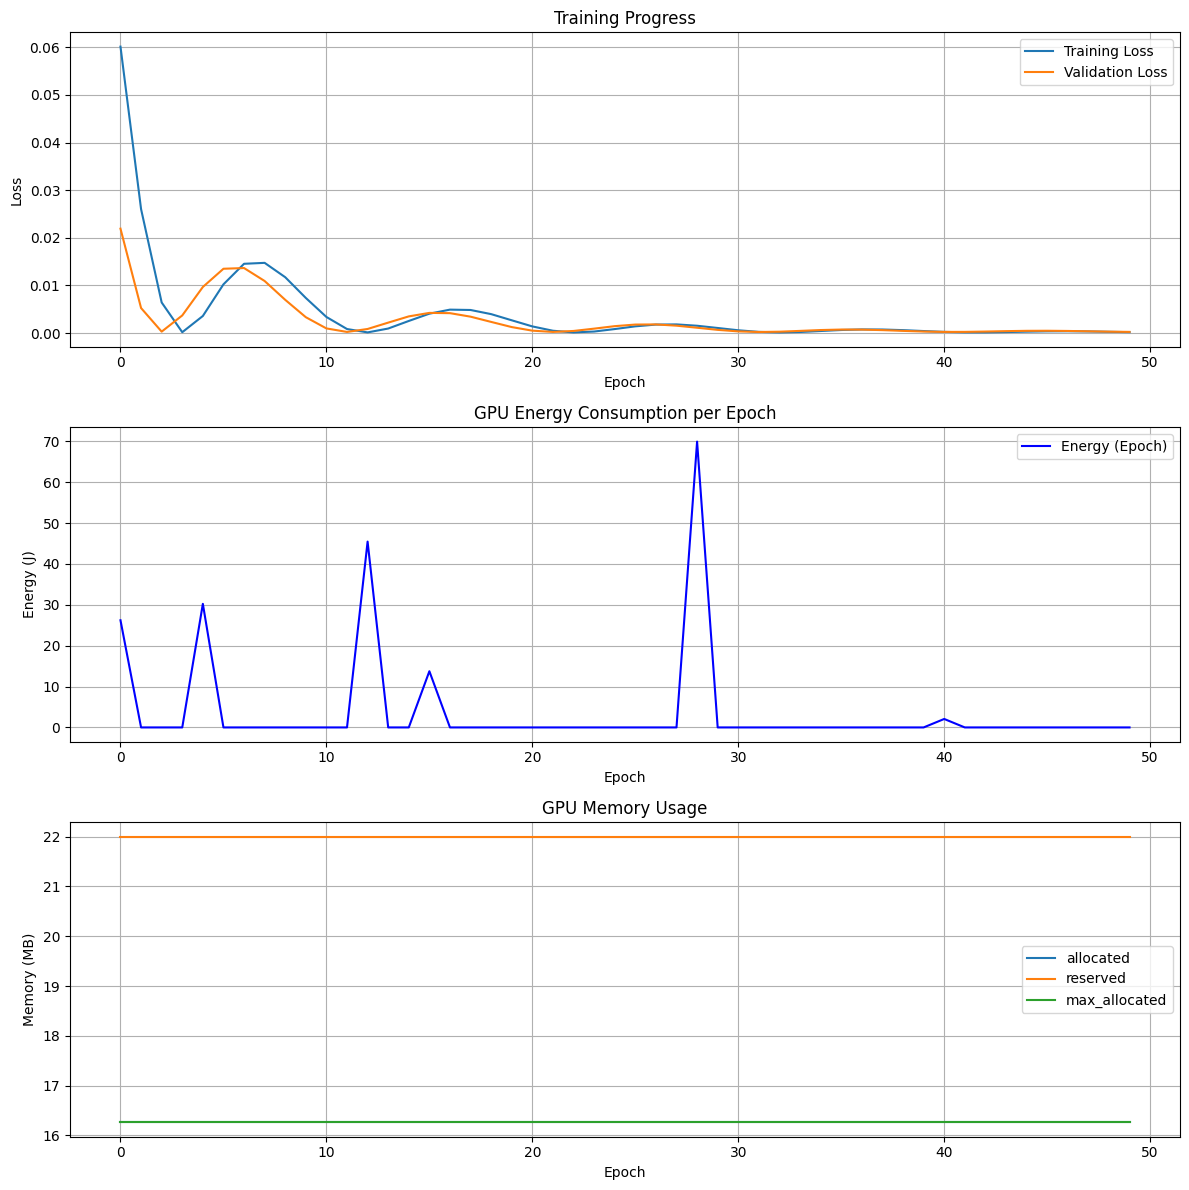

In [9]:
tracker.plot_metrics()

In [10]:
tracker.total_energy

187.66800000000512

In [11]:
tracker.metrics["memory"].keys()
total_memory_allocated = sum(tracker.metrics["memory"]["allocated"])
total_memory_reserved = sum(tracker.metrics["memory"]["reserved"])
total_memory_max_allocated = sum(tracker.metrics["memory"]["max_allocated"])

print(f"Total Memory Allocated: {total_memory_allocated}")
print(f"Total Memory Reserved: {total_memory_reserved}")
print(f"Total Memory Max Allocated: {total_memory_max_allocated}")


Total Memory Allocated: 813.037109375
Total Memory Reserved: 1100.0
Total Memory Max Allocated: 813.28125


In [12]:
x_test, y_true = load_test_data(cities, ALL_DIR=ALL_DIR)
y_true.to(device)

Node feature shape (test): torch.Size([3, 8])
Node label shape (test): torch.Size([3, 2])


tensor([[0.1873, 0.1696],
        [0.1878, 0.1411],
        [0.1464, 0.1528]], device='cuda:0')

In [13]:
test_data = Data(x=x_test, edge_index=edge_index, y=y_true)
test_data.to(device)

Data(x=[3, 8], edge_index=[2, 6], y=[3, 2])

In [14]:
# # rescale the predictions based on 'O3': {'min': -5.0, 'max': 205.0},
# #  'NO2': {'min': -2.6, 'max': 177.6},

# from modelling.denormalise import denormalise

# # Check the dimensions of y_pred
# print(f"y_pred shape before denormalization: {y_pred.shape}")

# # For 2D tensor (nodes x features), reshape to 3D (batch=1 x nodes x features)
# if len(y_pred.shape) == 2:
#     y_pred_3d = y_pred.unsqueeze(0)  # Add batch dimension
#     y_pred_3d = denormalise(y_pred_3d, ALL_DIR / 'minmax.csv')
#     y_pred = y_pred_3d.squeeze(0)  # Remove batch dimension
# else:
#     y_pred = denormalise(y_pred, ALL_DIR / 'minmax.csv')

# print(f"y_pred shape after denormalization: {y_pred.shape}")

# # Check the dimensions of y_true
# print(f"y_true shape before denormalization: {y_true.shape}")

# # For 2D tensor (nodes x features), reshape to 3D (batch=1 x nodes x features)
# if len(y_true.shape) == 2:
#     y_true_3d = y_true.unsqueeze(0)  # Add batch dimension
#     y_true_3d = denormalise(y_true_3d, ALL_DIR / 'minmax.csv')
#     y_true = y_true_3d.squeeze(0)  # Remove batch dimension
# else:
#     y_true = denormalise(y_true, ALL_DIR / 'minmax.csv')
    

In [15]:
# import torch.nn.functional as F

# y_pred = y_pred.to(device)
# y_true = y_true.to(device)

# mse = F.mse_loss(y_pred, y_true)
# rmse = torch.sqrt(mse)
# print(f"Test RMSE: {rmse.item()}")


In [ ]:
import torch
import numpy as np
from typing import Any, Dict
from torch_geometric.data import Batch
from modelling.denormalise import denormalise

def test_separately_gnn(
    model: Any,
    loss_fn: Any,
    test_loader: Any,
    denorm: bool = False,
    path: str = None,
    components=["NO2", "O3"],
) -> Dict[str, float]:
    """
    Evaluates a GNN model on the test set and returns test loss.

    :param model: GNN model to evaluate
    :param loss_fn: loss function to use
    :param test_loader: PyTorch Geometric DataLoader for graph batches
    :param denorm: whether to denormalise predictions and targets
    :param path: path to the file containing min/max values for denormalisation
    :return: Dictionary with contaminant names as keys and losses as values
    """
    model.eval()
    test_losses = [np.float64(0) for _ in components]

    with torch.no_grad():
        for batch in test_loader:  # batch is a Batch object
            batch = batch.to(next(model.parameters()).device)  # Move to model device
            pred = model(batch)  # Forward pass
            
            if denorm:
                pred = denormalise(pred, path)
                batch.y = denormalise(batch.y, path)

            # Compute loss per component (pollutant)
            for comp in range(len(components)):
                test_losses[comp] += loss_fn(
                    pred[:, comp], batch.y[:, comp]
                ).item()

    # Normalize by dataset size
    for comp in range(len(components)):
        test_losses[comp] /= len(test_loader)

    return {comp: loss for comp, loss in zip(components, test_losses)}


In [20]:
from torch_geometric.loader import DataLoader
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

test_loader

In [21]:
import torch.nn.functional as F

test_separately_gnn(model, F.mse_loss, test_loader, denorm=True, path=ALL_DIR / 'minmax.csv')

KeyError: 0